In [4]:
import os
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq.chat_models import ChatGroq
from dotenv import load_dotenv


load_dotenv()

True

In [5]:
llm= ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    api_key= os.getenv("GROQ_API_KEY")
)

In [6]:
class SubState(TypedDict):
    input_text:str
    translated_text:str

In [7]:
def translate_text(state:SubState):
    prompt= f"""
    Translate the following text to Hindi.
    Keep it natural and clear. Do not add extra content.

    Text:
    {state['input_text']}
    """.strip()

    translated_text= llm.invoke(prompt).content

    return {"translated_text":translated_text}

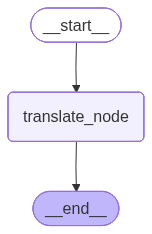

In [8]:
subgraph_builder= StateGraph(SubState)

subgraph_builder.add_node("translate_node", translate_text)

subgraph_builder.add_edge(START, "translate_node")
subgraph_builder.add_edge("translate_node", END)

subgraph= subgraph_builder.compile()

subgraph

In [9]:
class ParentState(TypedDict):
    question:str
    answer_eng:str 
    answer_hin: str 

In [11]:
def chat_point(state: ParentState):
    result= llm.invoke(state['question']).content

    return {"answer_eng": result}

def translater(state: ParentState):
    result= subgraph.invoke({"input_text":state['answer_eng']})['translated_text']

    return {"answer_hin": result}



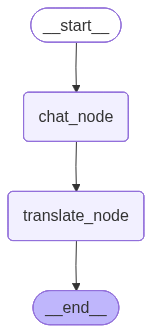

In [13]:
parent_builder= StateGraph(ParentState)

parent_builder.add_node('chat_node', chat_point)
parent_builder.add_node('translate_node', translater)


parent_builder.add_edge(START, 'chat_node')
parent_builder.add_edge("chat_node", "translate_node")
parent_builder.add_edge("translate_node", END)

parent_graph= parent_builder.compile()
parent_graph

In [14]:
initial_state= {"question": "who is the prime minister of india?"}

result= parent_graph.invoke(initial_state)
result

{'question': 'who is the prime minister of india?',
 'answer_eng': 'The Prime Minister of India is **Narendra Modi**. He has been serving as the Prime Minister of India since May 26, 2014. He represents the Bharatiya Janata Party (BJP) and is currently the leader of the National Democratic Alliance (NDA) government. \n\nIf you need more information or have other questions, feel free to ask!',
 'answer_hin': 'भारत के प्रधान मंत्री **नरेंद्र मोदी** हैं। वह 26 मई, 2014 से भारत के प्रधान मंत्री के रूप में कार्य कर रहे हैं। वह भारतीय जनता पार्टी (भाजपा) का प्रतिनिधित्व करते हैं और वर्तमान में राष्ट्रीय लोकतांत्रिक गठबंधन (एनडीए) सरकार के नेता हैं। \n\nयदि आपको अधिक जानकारी चाहिए या आपके पास अन्य प्रश्न हैं, तो पूछने में संकोच न करें!'}